In [8]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.21.0
Num GPUs Available: 0


In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os

# Paths
DATA_DIR = "/Users/parivat/Desktop/smart-waste-classifier/data/"
MODEL_DIR = "models/"
os.makedirs(MODEL_DIR, exist_ok=True)

# Config
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 10
NUM_CLASSES = 6

print("All imports successful ✅")

# Imports all libraries we need for the entire project
# DATA_DIR → points to your dataset folder
# MODEL_DIR → where the trained model will be saved
# IMAGE_SIZE → EfficientNetB0 expects 224×224 images
# BATCH_SIZE → 32 images processed at a time
# NUM_CLASSES → 6 waste categories

All imports successful ✅


In [17]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# No augmentation for validation — only preprocessing
val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    validation_split=0.2
)

# Training data
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Validation data
val_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print("Classes found:", train_generator.class_indices)
print("Training images:", train_generator.samples)
print("Validation images:", val_generator.samples)




# preprocessing_function → Scales images correctly for EfficientNet (-1 to 1). This is the critical bug we discussed earlier — wrong preprocessing kills accuracy.
# validation_split=0.2 → Automatically splits 80% for training, 20% for validation from your data folder.
# Data Augmentation → Artificially increases dataset size by slightly modifying training images:

# rotation_range=20 → rotates image up to 20 degrees
# horizontal_flip=True → flips image left-right
# zoom_range=0.2 → zooms in slightly

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Classes found: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Training images: 2024
Validation images: 503


In [ ]:
# Load EfficientNetB0 base — pretrained on ImageNet, without the top classification layer
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base — don't touch pretrained weights in Phase 1
base_model.trainable = False

# Build the full model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# include_top=False → removes EfficientNet's original ImageNet classification head so we can add our own
# base_model.trainable = False → freezes all pretrained weights — Phase 1 only trains our new head
# GlobalAveragePooling2D → compresses feature maps into a single vector
# Dense(256) + ReLU → learns waste-specific patterns
# Dropout(0.3) → prevents overfitting
# Dense(6) + Softmax → outputs probability for each of the 6 classes
# Adam lr=1e-3 → good learning rate for Phase 1 head-only training

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='models/best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)
]

# Phase 1 — Train only the head
print("Phase 1 Training — Head Only 🚀")
history1 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)


# EarlyStopping → stops training if val_loss doesn't improve for 3 epochs
# ModelCheckpoint → saves the best model automatically to models/best_model.keras
# ReduceLROnPlateau → reduces learning rate if progress stalls
# model.fit → starts Phase 1 training — only the head learns, base stays frozen

Phase 1 Training — Head Only 🚀
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6418 - loss: 0.9390
Epoch 1: val_accuracy improved from None to 0.80915, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.7490 - loss: 0.6837 - val_accuracy: 0.8091 - val_loss: 0.5132 - learning_rate: 0.0010
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8657 - loss: 0.3770
Epoch 2: val_accuracy improved from 0.80915 to 0.82107, saving model to models/best_model.keras

Epoch 2: finished saving model to models/best_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.8710 - loss: 0.3634 - val_accuracy: 0.8211 - val_loss: 0.4642 - learning_rate: 0.0010
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9112 - loss: 0.2675
Epoch 3: val_accuracy improved from 0.82107 to 0.84692, saving model to models/best_model.keras

Epoch 3: finished saving model to mo

In [20]:
# Unfreeze top 20 layers of EfficientNetB0
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with a much lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Trainable layers in Phase 2:", sum([1 for l in model.layers if l.trainable]))
print("\nPhase 2 Training — Fine Tuning 🚀")

history2 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE2,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Trainable layers in Phase 2: 5

Phase 2 Training — Fine Tuning 🚀
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8821 - loss: 0.3487
Epoch 1: val_accuracy did not improve from 0.87475
64/64 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.8913 - loss: 0.3271 - val_accuracy: 0.8628 - val_loss: 0.4033 - learning_rate: 1.0000e-05
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8891 - loss: 0.3223
Epoch 2: val_accuracy did not improve from 0.87475

Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
64/64 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.9066 - loss: 0.2877 - val_accuracy: 0.8489 - val_loss: 0.4118 - learning_rate: 1.0000e-05
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9227 - loss: 0.2743
Epoch 3: val_accuracy did not improve from 0.87475
64/64 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9190 - loss: 0.2825 - val_accuracy: 0.8469 - val_loss: 0.4278 - learning_rate: 2.0000e-06
Epoch 3: early stopping

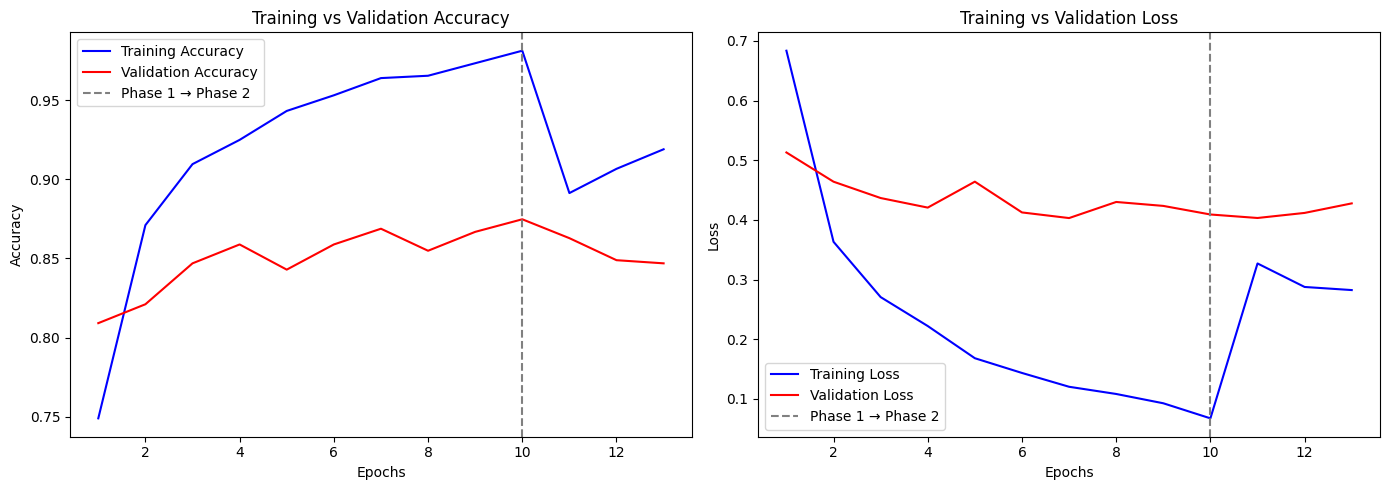

Training curves saved ✅


In [21]:
import matplotlib.pyplot as plt

# Combine both phases
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.axvline(x=EPOCHS_PHASE1, color='gray', linestyle='--', label='Phase 1 → Phase 2')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.axvline(x=EPOCHS_PHASE1, color='gray', linestyle='--', label='Phase 1 → Phase 2')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('models/training_curves.png')
plt.show()
print("Training curves saved ✅")